## Introduction to Seaborn: statistical data visualization
<table><border=0><tr><td><img src="http://seaborn.pydata.org/_static/scatterplot_matrix_thumb.png" width="100"></td><td><img src="http://seaborn.pydata.org/_static/errorband_lineplots_thumb.png" width="100"></td><td><img src="http://seaborn.pydata.org/_static/scatterplot_sizes_thumb.png" width="100"></td><td><img src="http://seaborn.pydata.org/_static/timeseries_facets_thumb.png" width="100"></td><td><img src="http://seaborn.pydata.org/_static/horizontal_boxplot_thumb.png" width="100"></td><td><img src="http://seaborn.pydata.org/_static/regression_marginals_thumb.png" width="100"></td></tr></table>
    

[Seaborn_API_reference](http://seaborn.pydata.org/api.html)
    
In this document we will learn how to create meaningful visualization that helps summarize the large amount of data effectively. We are introducing two libraries; matplotlib and seaborn.

It's common to use `sns` as an alias for seaborn. We will also use the `pyplot` module from the `matplotlib` package, and we will use `plt` as the alias.

Recall the magic function `%matplotlib inline`. This is a special Juypter command that renders and displays the plot in Juypter notebook.

In [ ]:
### Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
### The input file is tab-delimited
tsv_Filepath = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/euk.tsv"

## Load in the tsv file into DataFrame. Remember we can specify the delimiter by using the sep keyword argument

euk = pd.read_csv(tsv_Filepath, sep='\t')
euk.head()


,Species,Kingdom,Class,Size (Mb),GC%,Number of genes,Number of proteins,Publication year,Assembly status
0,Emiliania huxleyi CCMP1516,Protists,Other Protists,167.676,64.5,38549,38554,2013,Scaffold
1,Arabidopsis thaliana,Plants,Land Plants,119.669,36.0529,38311,48265,2001,Chromosome
2,Glycine max,Plants,Land Plants,979.046,35.1153,59847,71219,2010,Chromosome
3,Medicago truncatula,Plants,Land Plants,412.924,34.047,37603,41939,2011,Chromosome
4,Solanum lycopersicum,Plants,Land Plants,828.349,35.6991,31200,37660,2010,Chromosome


In [3]:
### What columns are in this dataset, their datatype, and the size of the dataframe?

euk.info()
print("Rows and columns:", euk.shape)


<class 'pandas.DataFrame'>
RangeIndex: 8302 entries, 0 to 8301
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Species             8302 non-null   str    
 1   Kingdom             8302 non-null   str    
 2   Class               8302 non-null   str    
 3   Size (Mb)           8302 non-null   float64
 4   GC%                 8302 non-null   str    
 5   Number of genes     8302 non-null   str    
 6   Number of proteins  8302 non-null   str    
 7   Publication year    8302 non-null   int64  
 8   Assembly status     8302 non-null   str    
dtypes: float64(1), int64(1), str(7)
memory usage: 583.9 KB
Rows and columns: (8302, 9)


### Data cleaning
Notice that the fields `Species`, `Kingdom`, `Class`, and `Assembly status` all contain strings, and some of the numeric fields contains "-" instead of a number.

To clean the data, let's
* Use dictionary to cast dtypes to change `Species`, `Kingdom`, `Class`, and `Assembly status` to string
* Pass the dictionary when loading DataFrame using `dtype` parameter
* Replace the "-" in the numeric field with NaN value when loading DataFrame using `na_values` parameter

In [4]:
### User dictionary that will be used to cast dtypes to change Species, Kingdom, Class, and Assembly status into string
my_types={
    "Species":"string",
    "Kingdom":"string",
    "Class":"string",
    "Assembly status":"string"
}

### Read in DataFrame. Use parameters dtypes and na_values

euk = pd.read_csv(tsv_Filepath, sep='\t', dtype=my_types, na_values='-')
euk.head()


,Species,Kingdom,Class,Size (Mb),GC%,Number of genes,Number of proteins,Publication year,Assembly status
0,Emiliania huxleyi CCMP1516,Protists,Other Protists,167.676,64.5000,38549.0,38554.0,2013,Scaffold
1,Arabidopsis thaliana,Plants,Land Plants,119.669,36.0529,38311.0,48265.0,2001,Chromosome
2,Glycine max,Plants,Land Plants,979.046,35.1153,59847.0,71219.0,2010,Chromosome
3,Medicago truncatula,Plants,Land Plants,412.924,34.0470,37603.0,41939.0,2011,Chromosome
4,Solanum lycopersicum,Plants,Land Plants,828.349,35.6991,31200.0,37660.0,2010,Chromosome


In [ ]:
### Check the datatype of string columns
euk.dtypes

,0
Species,string[python]
Kingdom,string[python]
Class,string[python]
Size (Mb),float64
GC%,float64
Number of genes,float64
Number of proteins,float64
Publication year,int64
Assembly status,string[python]


In [ ]:
### Check .info() again. What do you notice?
euk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8302 entries, 0 to 8301
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Species             8302 non-null   string 
 1   Kingdom             8302 non-null   string 
 2   Class               8302 non-null   string 
 3   Size (Mb)           8302 non-null   float64
 4   GC%                 7895 non-null   float64
 5   Number of genes     2372 non-null   float64
 6   Number of proteins  2371 non-null   float64
 7   Publication year    8302 non-null   int64  
 8   Assembly status     8302 non-null   string 
dtypes: float64(4), int64(1), string(4)
memory usage: 583.9 KB


## `catplot` - Categorical plot
In a previous lecture, we introduced `value_counts()` as a way to ask "how many?". To visualize these counts we can use seaborn's `catplot`. `catplot` takes in a long-form (tidy) dataframe for plotting. In a tidy dataframe, each column should correspond to a variable, and each row should correspond to an observation. Here we created a tidy dataframe, "animals_df", that contains the Class name of each observation of an Animal.

### Convert a Series to a DataFrame
First task we will do is to create a tidy dataframe, "animals_df", that contains the Class name of each observation of an Animal. We will first create a Series of all the Animals and then convert that Series to a DataFrame using the function `to_frame()`.

In [7]:
### Use to_frame() to convert a Series to a Dataframe
animals_df = euk.Class[(euk.Kingdom == "Animals")] #this is a Series
## Convert to DataFrame
animals_df = animals_df.to_frame()


## Rename the column to "Animals"
animals_df.columns = ['Animals']


#### Types of `catplot`
There are many kinds of sns `catplot`. Here we are setting `x = 'Animals'` and `kind = 'count'` because we are plotting barplot that represents the counts of each unique observation (ie., counts of each unique types of Animals).

Other kind of catplots include strip, swarm, box, violin, boxen, point, bar, or count. To learn more, see the resource [seaborn.catplot](https://seaborn.pydata.org/generated/seaborn.catplot.html). We will cover some of these plots in a future class.

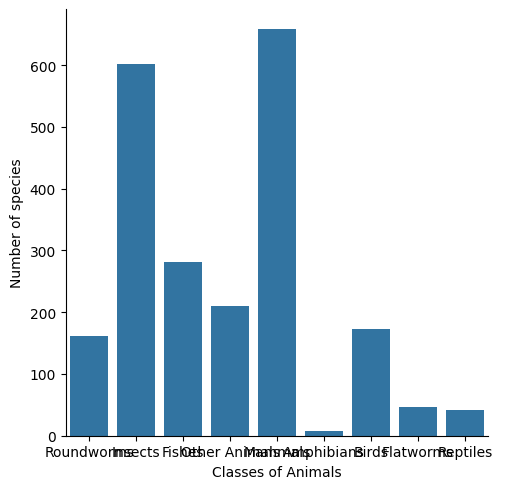

In [ ]:
### Create a barplot that counts the number of unique type of Animals
sns.catplot(
    data = animals_df,
    x = 'Animals',
    kind = 'count'
)

#### How can we improve the plot?
We can improve the plot by:
* Ordering the bars based on the height
* Swap the x and y axis to avoid having overlapping data along the x-axis
* (optional) Use color. Here we don't really need different colors for each bar in this plot since the bars are already labeled. However, if you want to change the color of the bars, you can set the `color` to "darkblue".

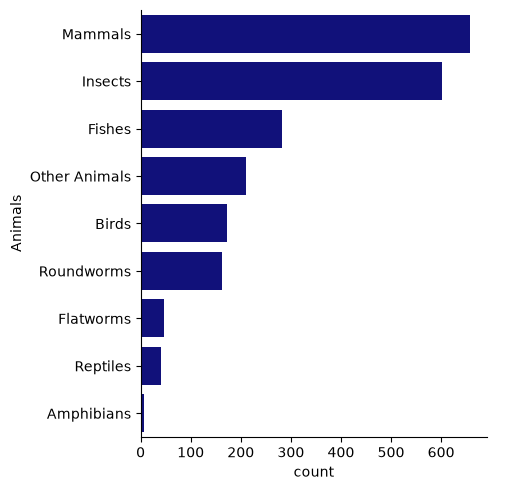

In [9]:
### Improving the barplot
sns.catplot(
    data = animals_df,
    y = "Animals",
    kind = 'count',
    order = animals_df['Animals'].value_counts().index,
    color = 'darkblue'
   )


####  `order` and `value_counts()` to count unique instances
Let's take a closer look at the `order` argument. We use `value_counts()` to get the counts of each unique Animals. The resulting Series output by `value_counts()` is already sorted. Simply add `.index` to get the index of each Class of Animals in the sorted order.

In [ ]:
animals_df['Animals'].value_counts().index

Index(['Mammals', 'Insects', 'Fishes', 'Other Animals', 'Birds', 'Roundworms',
       'Flatworms', 'Reptiles', 'Amphibians'],
      dtype='string', name='Animals')

#### Rotating the x-axis labels
What if we don't want to swap our x and y axis?  
Another way to display the axis labels is to rotate them so that they don't overlap with each other using `set_xticklabels`.

To be able to use the functions `.set_axis_labels` or  `set_xticklabels` at a another point, we need to create the store the sns.catplot as a variable. This is because these methods are applied to a FacetGrid object that sns.catplot returns.

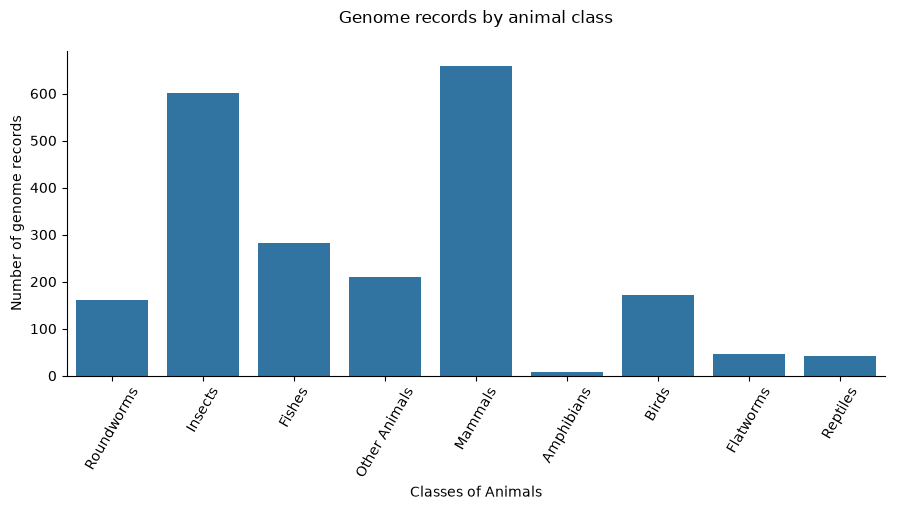

In [11]:
### Create catplot with methods to work with labels
# sns.catplot(
#     x = 'Animals',
#     data = animals_df,
#     kind = 'count'
# ).set_axis_labels('Classes of Animals', 'Number of species').set_xticklabels(rotation=300);

### Store the catplot as a FacetGrid object
bfo = sns.catplot(data=animals_df, x='Animals', kind='count', height=5, aspect=1.8)

### Apply methods to the bfo variable
bfo.set_axis_labels('Classes of Animals', 'Number of genome records')
bfo.set_xticklabels(rotation=60)

bfo.fig.subplots_adjust(bottom=0.32)
plt.title('Genome records by animal class', pad=20)
plt.show()


## Visualizing relationship between two variables

Now, let's face the truth. We are not very good at seeing patterns by reading large tables of data. For example, look at the following table that contains the "Size (Mb)" (genome size) and "Number of genes" for reptiles. Can you see the relationship between genome size and the number of genes?

In [12]:
### Filter for a particulr Class and remove outliers (where proteins > 1000)
landplant_protein = euk.loc[euk['Class'] == 'Land Plants']
landplant_protein = landplant_protein.loc[landplant_protein['Number of proteins'] > 1000]
landplant_protein[["Species", "Class", "Size (Mb)", "Number of genes"]].head()


,Species,Class,Size (Mb),Number of genes
1,Arabidopsis thaliana,Land Plants,119.669,38311.0
2,Glycine max,Land Plants,979.046,59847.0
3,Medicago truncatula,Land Plants,412.924,37603.0
4,Solanum lycopersicum,Land Plants,828.349,31200.0
6,Oryza sativa Japonica Group,Land Plants,374.423,35219.0


This is a small dataset, and it's already quite challenging to spot the relationship. Let's try to view this data by creating a scatter plot using Seaborn `scatterplot`.  

`sns.scatterplot(data=<DF>, x=<colx>, y=<coly>)`

Point out
* No title or axis label
* stdout text of the plot printed above plot

<Axes: xlabel='Size (Mb)', ylabel='Number of genes'>

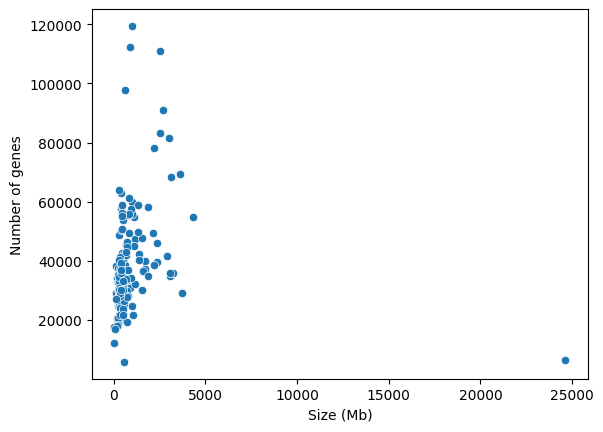

In [ ]:
### use scatterplot() to plot Size (Mb) vs. Number of genes
sns.scatterplot(data=landplant_protein, x="Size (Mb)", y="Number of genes")

## **Class Exercise CL7.1**
To compare genome compositional differences (GC%) among eukaryote classes, create a categorical plot using `catplot(kind="box")` to show GC% distributions across different classes.

*Hint*: Since there are many organisms in each Class, we will want to think about grouping (`groupby`) the Class together to get the mean value of the GC% per Class.

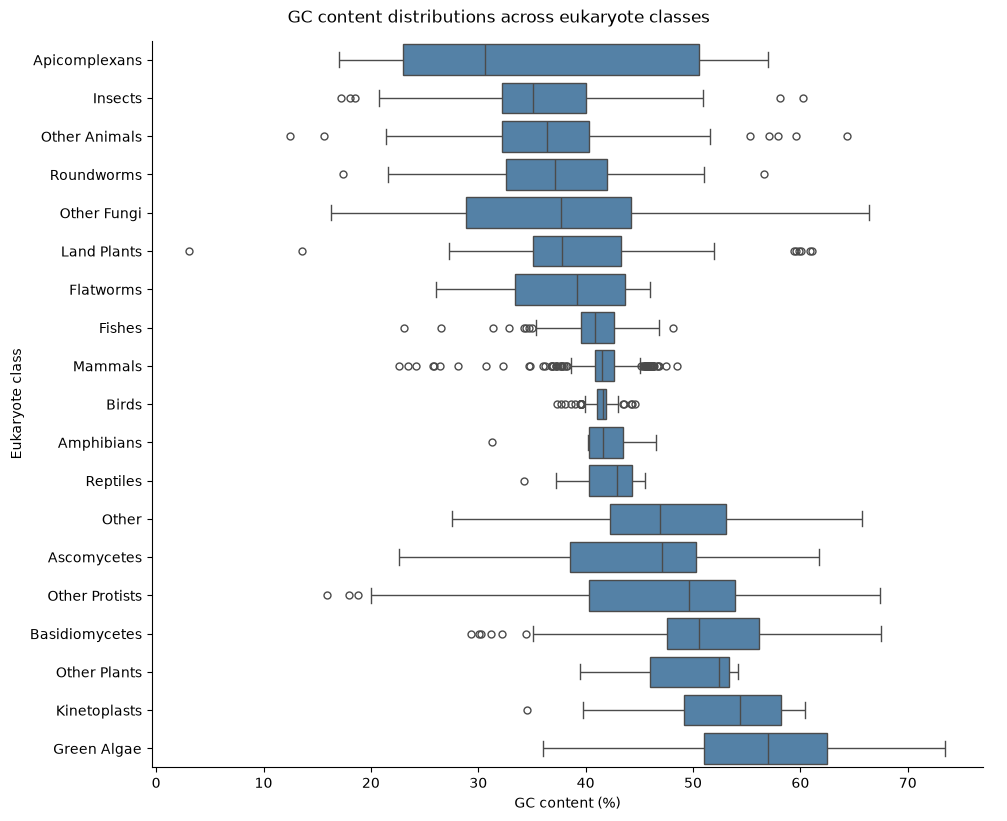

In [14]:
# Your code

# Use individual records for a distribution; group means alone cannot form a boxplot.
class_order = euk.groupby('Class')['GC%'].median().sort_values().index
g = sns.catplot(data=euk.dropna(subset=['Class', 'GC%']),
                x='GC%', y='Class', order=class_order, kind='box',
                height=8, aspect=1.25, color='steelblue')
g.set_axis_labels('GC content (%)', 'Eukaryote class')
g.fig.suptitle('GC content distributions across eukaryote classes', y=1.02)
plt.show()


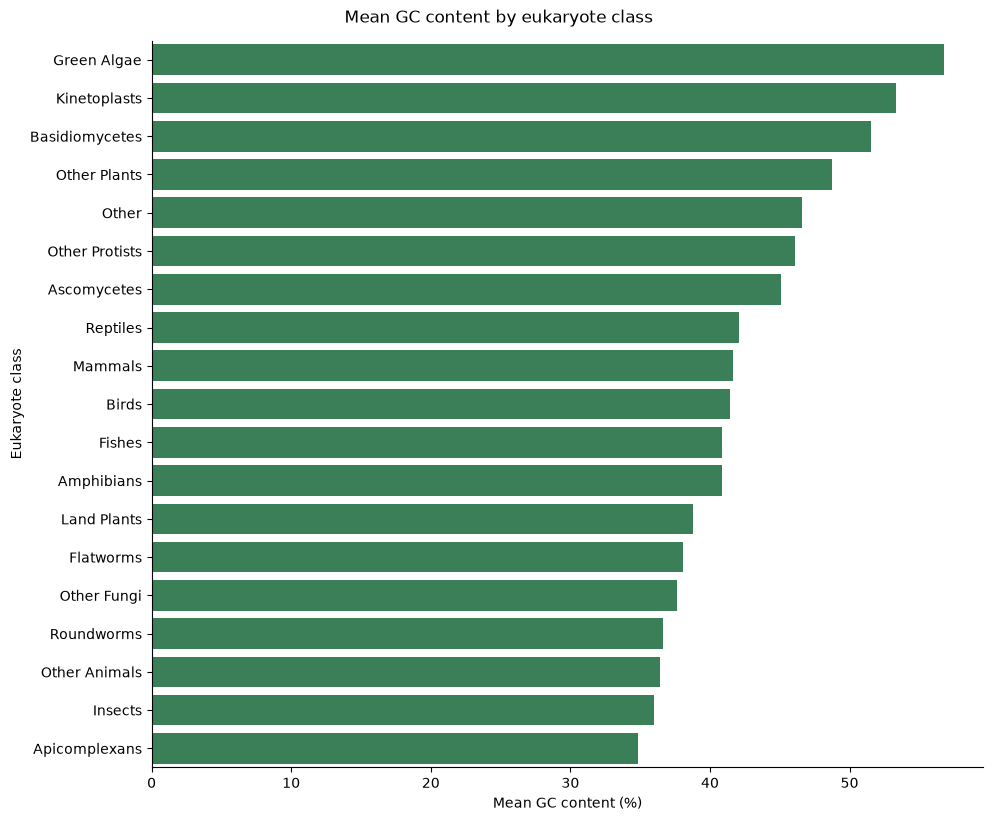

In [15]:
### Create a bar plot that takes the mean value of

mean_gc = euk.groupby('Class', as_index=False)['GC%'].mean().sort_values('GC%', ascending=False)
g = sns.catplot(data=mean_gc, x='GC%', y='Class', kind='bar',
                order=mean_gc['Class'], height=8, aspect=1.25, color='seagreen', errorbar=None)
g.set_axis_labels('Mean GC content (%)', 'Eukaryote class')
g.fig.suptitle('Mean GC content by eukaryote class', y=1.02)
plt.show()


## `relplot` - Relationship plot
We pass the dataframe into the [`relplot`](https://seaborn.pydata.org/generated/seaborn.relplot.html) function, and the names of the columns that we want on the `x` and `y` axes.  

`relplot` functions as a figure-level plot compared to `scatterplot` which functions as an axes-level plot. There are some differences between the two function as to why we would choose one or the other function. For EDA relplot is a better option with one of the advantage being that it allows us to create multi-plot grids.

## **Class Exercise CL7.2**
Let's look at the relationship between genome size and number of genes in the entire eukaryote genome dataset.

Create a relationship plot of all eukaryotic genome using `relplot()` (instead of `scatterplot`) to compare "Size (Mb)" vs. "Number of genes".

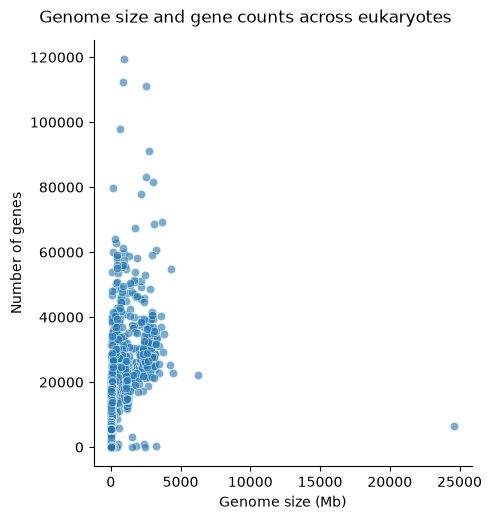

In [16]:
# Your code

g = sns.relplot(data=euk, x='Size (Mb)', y='Number of genes', kind='scatter', alpha=0.6)
g.set_axis_labels('Genome size (Mb)', 'Number of genes')
g.fig.suptitle('Genome size and gene counts across eukaryotes', y=1.03)
plt.show()


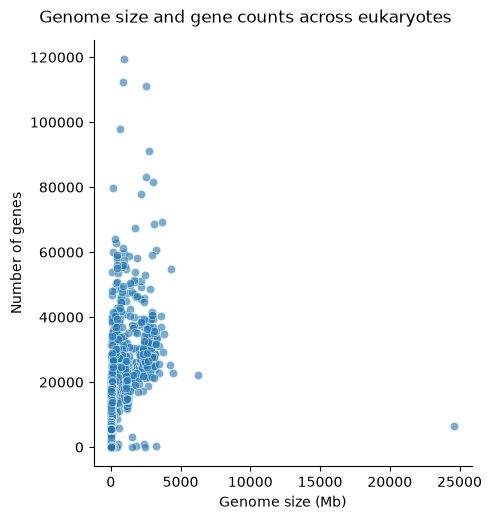

In [17]:
### Generate a relationship plot visualizng "Size (Mb)" vs. "Number of genes"

g = sns.relplot(data=euk, x='Size (Mb)', y='Number of genes', kind='scatter', alpha=0.6)
g.set_axis_labels('Genome size (Mb)', 'Number of genes')
g.fig.suptitle('Genome size and gene counts across eukaryotes', y=1.03)
plt.show()


It only takes a glance to see the positive correlation.

### Handling outlier in our visualization
The chart above shows a problem commonly encountered in real life data: there is a _single outlier_ with a massive genome size, which compresses the rest of the data points over to the left and makes it difficult to see the patterns.

We could fix this by manually setting the x-axis limits (using `plt.xlim(min, max)`). Another approach is to filter the dataframe and exclude very large genomes.

## **Class Exercise CL7.3**
Let's look at the relationship between genome size and number of genes in the entire eukaryote genome dataset.

Create a relationship plot of all eukaryotic genome using `relplot` comparing "Size (Mb)" vs. "Number of genes".

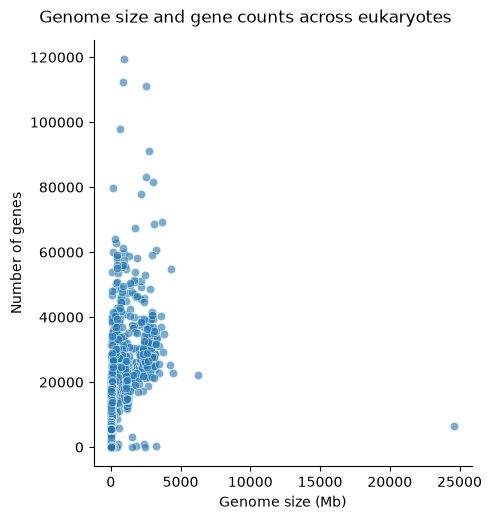

In [18]:
# Your code

g = sns.relplot(data=euk, x='Size (Mb)', y='Number of genes', kind='scatter', alpha=0.6)
g.set_axis_labels('Genome size (Mb)', 'Number of genes')
g.fig.suptitle('Genome size and gene counts across eukaryotes', y=1.03)
plt.show()


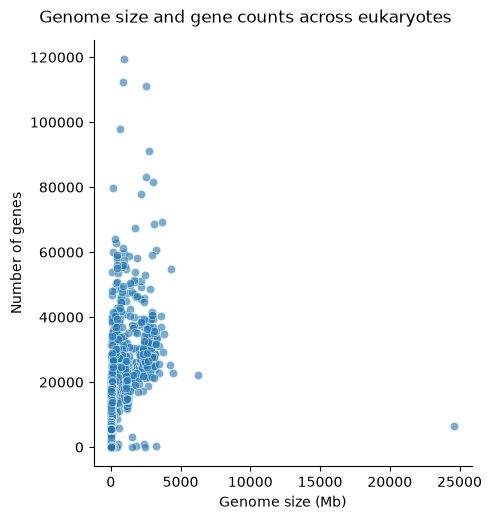

In [19]:
### Generate a relationship plot visualizng "Size (Mb)" vs. "Number of genes"

g = sns.relplot(data=euk, x='Size (Mb)', y='Number of genes', kind='scatter', alpha=0.6)
g.set_axis_labels('Genome size (Mb)', 'Number of genes')
g.fig.suptitle('Genome size and gene counts across eukaryotes', y=1.03)
plt.show()


The chart above shows a problem commonly encountered in real life data: there is a _single outlier_ with a massive genome size, which compresses the rest of the data points over to the left and makes it difficult to see the patterns.

We could fix this by manually setting the x-axis limits (using `plt.xlim(min, max)`). Another approach is to filter the dataframe and exclude very large genomes.

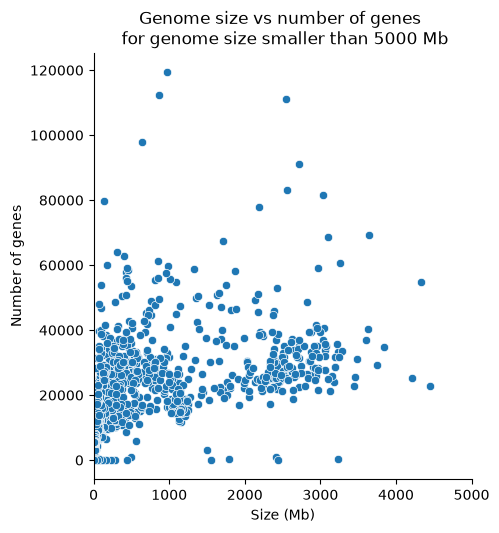

In [20]:
### Manually set the x-axis limit
sns.relplot(data=euk,
    x="Size (Mb)",
    y="Number of genes"
    )

plt.xlim(0, 5000)
plt.title("Genome size vs number of genes \n for genome size smaller than 5000 Mb");


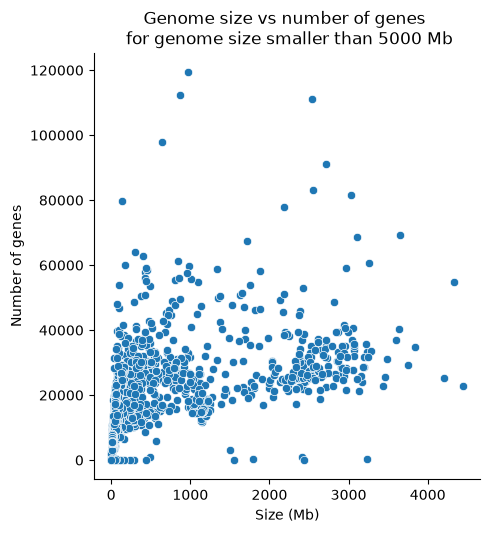

In [21]:
### Exclude the outlier by filtering the DataFrame
sns.relplot(data=euk[euk["Size (Mb)"] < 5000],
    x="Size (Mb)",
    y="Number of genes"
)

plt.title("Genome size vs number of genes \n for genome size smaller than 5000 Mb");


## **Class Exercise CL7.4**
Let's look at another relationship. This time let's filter our data to explore the relationship between genome size and number of genes focusing only on Reptiles.

Create a relationship plot of Reptile with less than 1000 proteins and their genome size.

1 record meets this filter; one point cannot establish a trend.


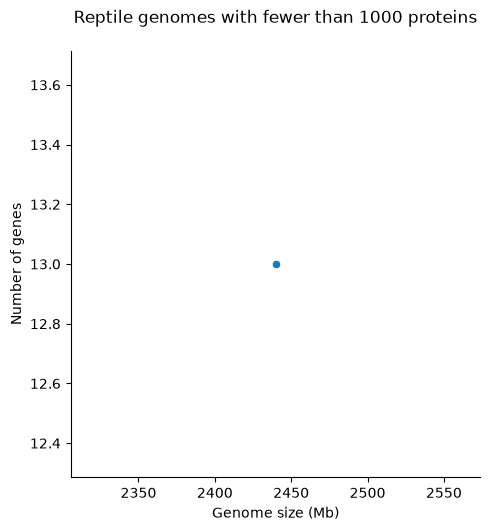

In [22]:
### Filter DataFrame for Reptiles and Number of proteins
reptile_protein = euk.loc[
    (euk['Class'] == 'Reptiles') & (euk['Number of proteins'] < 1000)
]

### Generate a scatterplot (via relplot) to quickly look at the relationship between size of genome and number of genes


## Use plt.title to give name, pad= to pad the title, and semicolon(;) at end to omit the stdout text of the plot

g = sns.relplot(data=reptile_protein, x='Size (Mb)', y='Number of genes')
g.set_axis_labels('Genome size (Mb)', 'Number of genes')
plt.title('Reptile genomes with fewer than 1000 proteins', pad=20)
print(f'{len(reptile_protein)} record meets this filter; one point cannot establish a trend.')
plt.show()


## Adding color using `hue`
Rather than giving `relplot` a collection of x and y values to plot, instead we give it the whole dataframe and then specify which columns we want to determine the x and y positions of each point.

The benefits of this way of thinking about plots become clear when we start mapping other properties. By setting the `hue` argument we can specify which column we want to determine the color of each point. Here is another plot of genome size versus number of genes. We will limit the plot to animals and associated GC percentage represented by _hue_.

**DNA has 4 building blocks**
`A`, `T`, `C`, and `G`

DNA_seq = "ATCCGTAGTATACGGATCGTAGATTATACGGACGAGTCGACTGACTGACT"

GC% is the proportion of the DNA sequence containing Gs and Cs. Based on GC% of the DNA, we can tell, whether we are looking at the DNA of a particular organism.

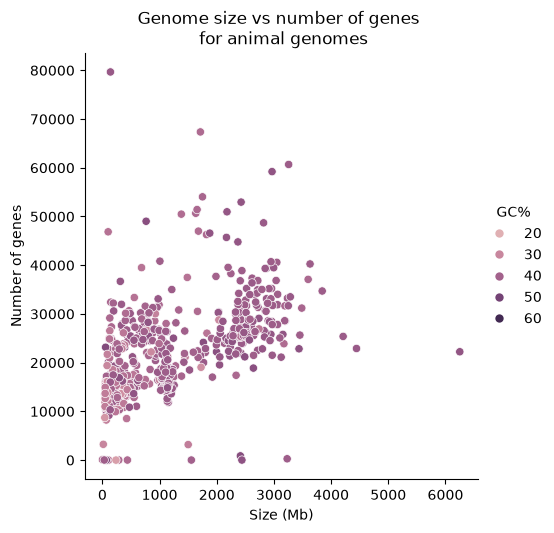

In [23]:
### Plot the relationship of "Size (Mb)" vs "Number of genes" while scaling color of plot on GC%
sns.relplot(
    data = euk[(euk["Kingdom"]=="Animals")],
    x = "Size (Mb)",
    y = "Number of genes",
    hue = "GC%"
)
plt.title("Genome size vs number of genes \n for animal genomes");


## **Class Exercise CL7.5**
Does including missing data influence the color scale of hue?

We will limit the plot to animals and associated GC percentage represented by hue. It is best to remove any rows with missing data before plotting our data so that it will not impact seaborn's ability to choose the color scales for the hue. We wil use panda's dropna() to do that.

Animal records before filtering: 2181
Complete records for the plotted variables: 613
GC% range used in the plot: 21.5777 51.5955


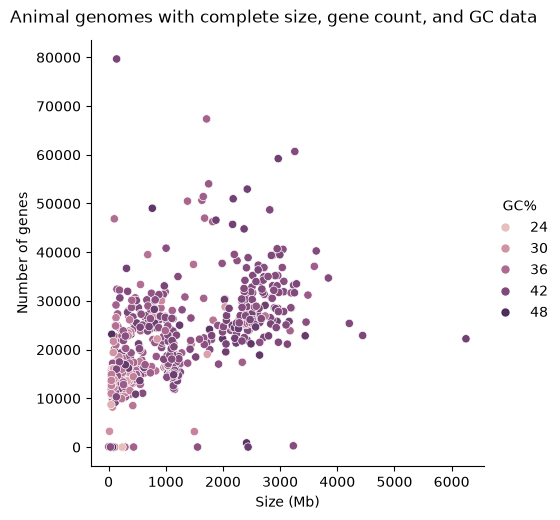

Seaborn omits records missing plotted values. Dropping missing values in these columns makes the plotted subset explicit. Dropping rows missing unrelated columns can remove additional observations and change the observed color range.


In [24]:
# Your code

animal_data = euk.loc[euk['Kingdom'] == 'Animals']
animal_complete = animal_data.dropna(subset=['Size (Mb)', 'Number of genes', 'GC%'])
print('Animal records before filtering:', len(animal_data))
print('Complete records for the plotted variables:', len(animal_complete))
print('GC% range used in the plot:', animal_complete['GC%'].min(), animal_complete['GC%'].max())
g = sns.relplot(data=animal_complete, x='Size (Mb)', y='Number of genes', hue='GC%')
g.fig.suptitle('Animal genomes with complete size, gene count, and GC data', y=1.03)
plt.show()
print('Seaborn omits records missing plotted values. Dropping missing values in these '
      'columns makes the plotted subset explicit. Dropping rows missing unrelated '
      'columns can remove additional observations and change the observed color range.')


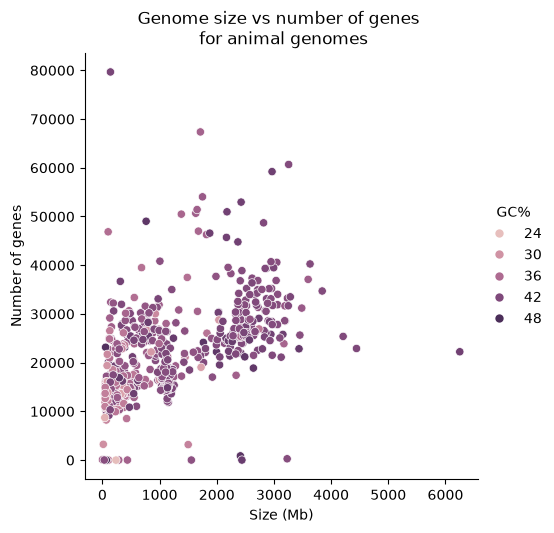

In [25]:
### We will drop the NA values since they do not contribute anything meaningful to the plot
sns.relplot(data = euk.loc[euk["Kingdom"] == "Animals"].dropna(subset=["Size (Mb)", "Number of genes", "GC%"]),
    x = "Size (Mb)",
    y = "Number of genes",
    hue = "GC%"
)

plt.title("Genome size vs number of genes \n for animal genomes");


We can distinguish the data point better once we remove the NA values. Could we improve the plot even more by choosing a different color palette?

You can choose different palette for using different colors by setting the `palette` argument in relplot. [seaborn_color_palettes](http://seaborn.pydata.org/tutorial/color_palettes.html)

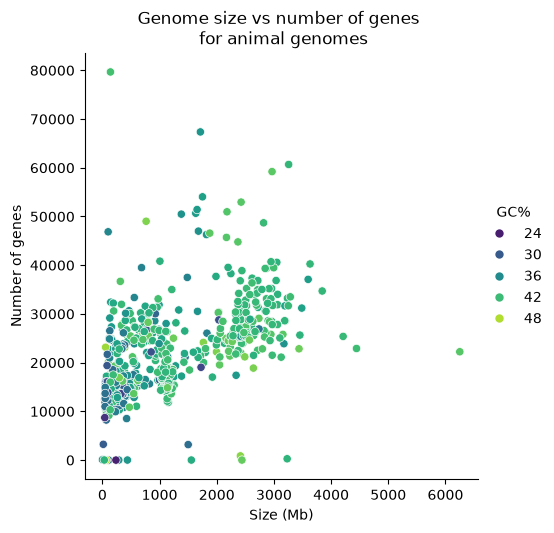

In [26]:
sns.relplot(
    data = euk[(euk["Kingdom"]=="Animals")].dropna(),
    x="Size (Mb)",
    y="Number of genes",
    hue="GC%",
    palette="viridis"
)
plt.title("Genome size vs number of genes \n for animal genomes");


### Working with size of data points
If we pick our mapping carefully, this lets us see multiple relationships between variables in a single plot. Unsurprisingly, larger genomes have more genes, and tend to have more moderate GC percentages - all the extremes of GC percentage (i.e. very light or dark colors) are over to the left of the chart.

Another property that we can map is the genome size of the data points. To plot the number of genes versus the number of proteins and have the *size* of each point determined by the size of the genome, we will use the `size` argument. The `size` argument maps the size of the dot (data point) to the size of the genome. The argument `sizes` determines the minimum and maximum sizes of the points we want on the plot.
  
`size=`: use this to set the column you want to map the size to   
`sizes=(min, max)`: Accepts a tuple indicating the sizs of the marker area to represent the value

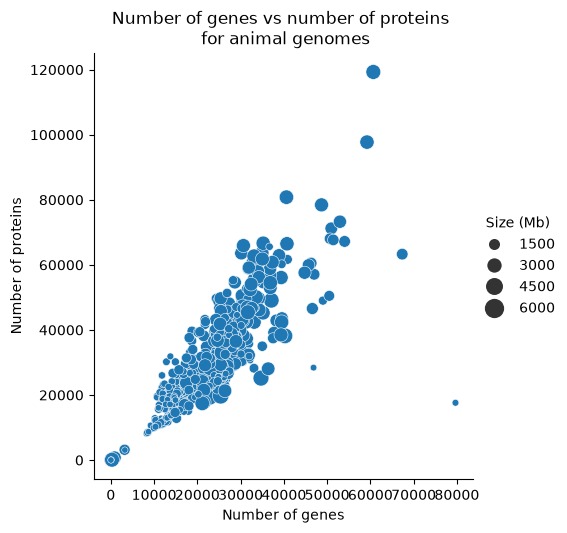

In [27]:
### Apply size to the column "Size (Mb)" and set the marker to be a particular size range
sns.relplot(
    data = euk[(euk["Kingdom"]=="Animals")].dropna(),
    x = "Number of genes",
    y = "Number of proteins",
    size="Size (Mb)", sizes=(20, 200)
)

plt.title("Number of genes vs number of proteins \n for animal genomes");


#### Combine parameters in visualization
We can combine `size` and `hue` to add more meaning to our visualization. To keep track of the genome size we will use `size` and to keep track of the publication year we will use `hue`.

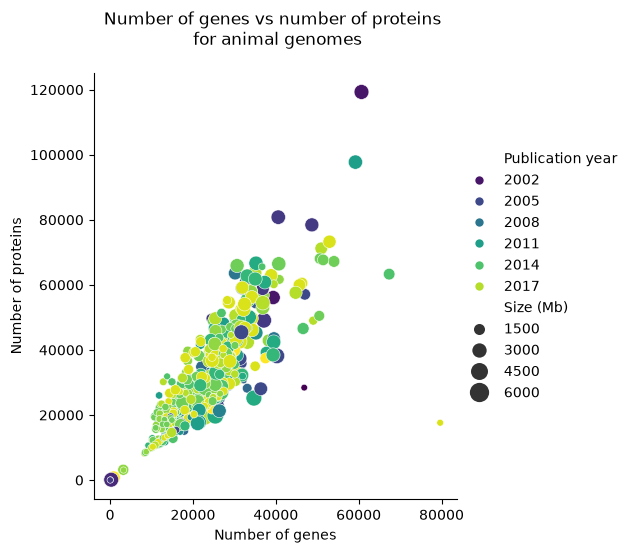

In [28]:
sns.relplot(
    data = euk[(euk["Kingdom"]=="Animals")].dropna(),
    x = "Number of genes",
    y = "Number of proteins",
    size = "Size (Mb)",
    sizes = (20, 200),
    hue = "Publication year",
    palette = "viridis"
)
plt.title("Number of genes vs number of proteins \n for animal genomes", pad=20);


### Drawback to too much data
As we add more details to our plot, it becomes harder to interpret. The relative
importance of the different point properties is determined by the way that our vision works.  

Research has shown that we find it easiest to see patterns in the position of the points (x and y), followed by the _size_ and finally the _hue_. We should take this into account when deciding which variables to map to which properties.

### For fun...let's look at gene density
Remember that the starting point for all of these plots is a pandas DataFrame. If we want to plot a new value such as gene density, we need to create a new column that was not part of the original DataFrame.

We will define gene density as the number of genes to the size of the genome.

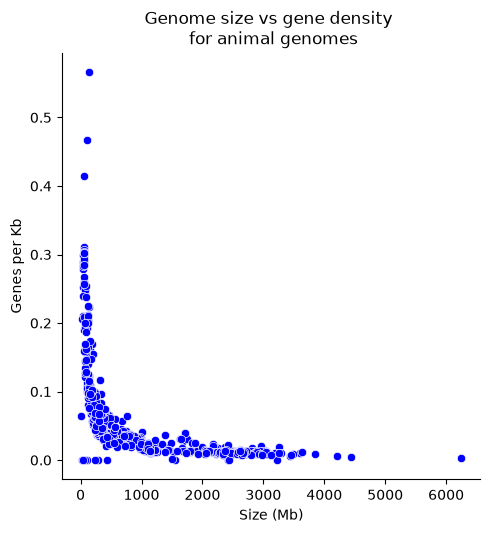

In [29]:
### Create a new column to calculate gene density
animals = euk[(euk["Kingdom"]=="Animals")].dropna()
animals["Genes per Kb"] = animals["Number of genes"] / (animals["Size (Mb)"] * 1000)

## Relationship plot to view gene density
sns.relplot(
    data = animals,
    x = "Size (Mb)",
    y = "Genes per Kb",
    color = "blue"
)

plt.title("Genome size vs gene density \n for animal genomes");


We know from our previous plots that there is a strong positive correlation between genome size and number of genes, but this plot tells us that the pattern is reversed for gene density. Large genomes may contain more genes, but the genes are spaced farther apart!

Although this result is not particularly surprising, it is reassuring to see it in such a clear figure.

## **Class Exercise CL7.6 (Group activity)**
Let's assume that you are aliens who just arrived to Earth. You do not know much about the different life on this planet, but your team member hacked the system and found this dataset. Come up with two questions you want to ask about this dataset. Before you even start plotting, take a moment to think about what you want to show in your plot.


Apply the different type of plots we learned in this notebook, including using different parameter to enhance your plot.

With your group, in the group's Google doc for each question include
list your questions, add your plots, and provide your interpretation of the

1. What is your question?
2. (optional) Try sketching out what you think the plot should look like
3. The code and resulting plot screenshot
4. Interpret the plot. Was the result as expected?


### Questions
* Q1: How do genome-size distributions differ among kingdoms?
* Q2: How does GC content vary among kingdoms?


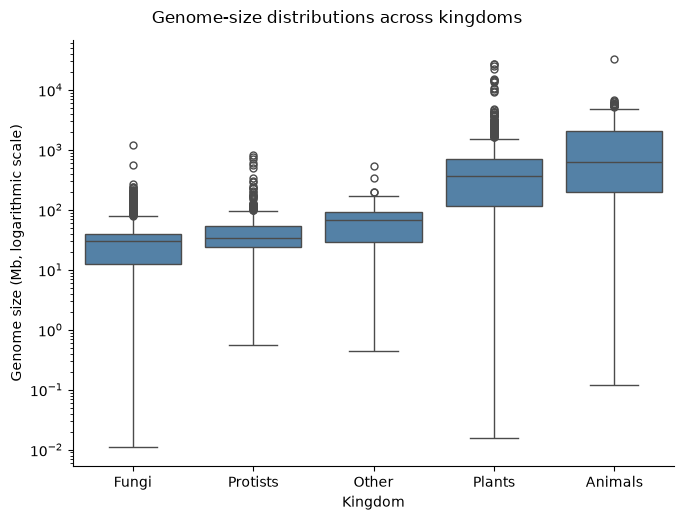

Kingdom
Animals     619.30100
Fungi        29.95100
Other        68.69715
Plants      364.02650
Protists     34.15200
Name: Size (Mb), dtype: float64

In [30]:
# Your code to answer Question 1

genome_sizes = euk.loc[euk['Size (Mb)'] > 0].dropna(subset=['Kingdom', 'Size (Mb)'])
kingdom_order = genome_sizes.groupby('Kingdom')['Size (Mb)'].median().sort_values().index
g = sns.catplot(data=genome_sizes, x='Kingdom', y='Size (Mb)', kind='box',
                order=kingdom_order, color='steelblue', height=5, aspect=1.4)
g.set(yscale='log')
g.set_axis_labels('Kingdom', 'Genome size (Mb, logarithmic scale)')
g.fig.suptitle('Genome-size distributions across kingdoms', y=1.03)
plt.show()
display(genome_sizes.groupby('Kingdom')['Size (Mb)'].median())


Animal and plant records have larger median genome sizes (about 619 Mb and 364 Mb) than fungal and protist records (about 30 Mb and 34 Mb). The distributions overlap and include extreme values, which are easier to compare on the logarithmic axis. The pattern is consistent with the expectation that genome size differs among kingdoms, but these are sampled genome records, not an unbiased census of life.


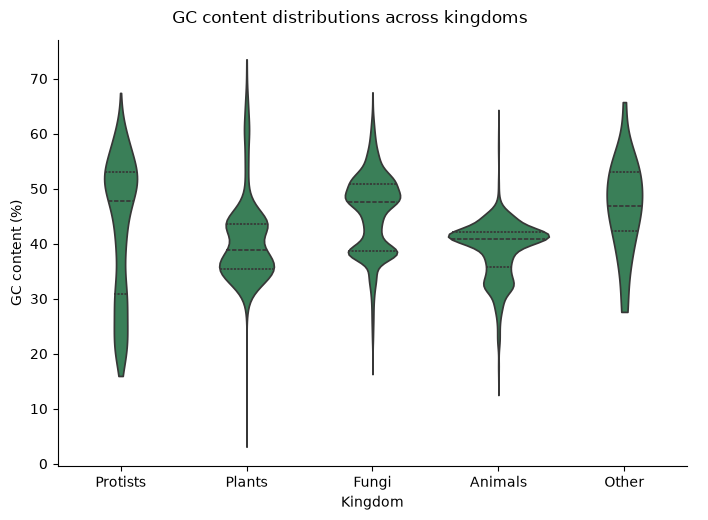

Kingdom
Animals     40.8000
Fungi       47.5000
Other       46.9050
Plants      38.8437
Protists    47.7000
Name: GC%, dtype: float64

In [31]:
# Your code to answer Question 2

gc_data = euk.dropna(subset=['Kingdom', 'GC%'])
g = sns.catplot(data=gc_data, x='Kingdom', y='GC%', kind='violin',
                cut=0, inner='quartile', color='seagreen', height=5, aspect=1.4)
g.set_axis_labels('Kingdom', 'GC content (%)')
g.fig.suptitle('GC content distributions across kingdoms', y=1.03)
plt.show()
display(gc_data.groupby('Kingdom')['GC%'].median())


Fungi and protists have median GC contents near 47.5% and 47.7%, compared with about 40.8% for animals and 38.8% for plants. The violin distributions overlap substantially, so GC content alone cannot reliably identify a kingdom. Differences in the centers are visible, but each kingdom also contains considerable variation.
